In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [1]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
dbd_norm_activities = pd.read_csv("../../../output/GCN4_pipeline/time_normalization/DBD_time_normalized_activities.csv")
dbd_norm_activities = dbd_norm_activities[["ADseq", "AD_BC", "RPTR_BC", "time", "rep", "shifted_activity"]]
# dbd_norm_activities = dbd_norm_activities.groupby(["ADseq", "rep", "time"])[["shifted_activity"]].agg(["mean", "std"]).reset_index()
# dbd_norm_activities.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in dbd_norm_activities.columns]
# dbd_norm_activities = dbd_norm_activities[dbd_norm_activities["rep_"] == 2]
# dbd_norm_activities = dbd_norm_activities.dropna()
dbd_norm_activities

,ADseq,AD_BC,RPTR_BC,time,rep,shifted_activity
0,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS,GCATATAGAGA,CCTGCTATTCGTAA,10,1,1.798322
1,SNTQAVTGQHRRHSSNLPSASSLQNQRVAAIIQSTGHSIS,CCACAGACGGA,TACCTCCGACTGTC,10,1,-0.573827
2,AEIRGGTRLVCRRENGHQVLQGVSHPPWRSKRSSPPDTPL,CAGACCAAGAA,GTGGTCAAGGCTCG,10,1,-0.103823
3,EVGDFSVNKPPQADDMVMSSRQEKGKQPDVATWDAHSNKG,ATTTGTACTAG,CCATGTTTGGCGAA,10,1,-0.381749
4,LASPHLLLVNVHCHEPMLSLLYTTDQVQNSGSLLPVSSTP,AACGTTCCTCA,ATATAAAGCGATTG,10,1,-0.074264
...,...,...,...,...,...,...
342856,LGPTVSPKDIFNIDSVPPSTSLTNLTTPGSTYLDTPDDSF,CCCCCTCACGC,CCCTGCCCCGTTAG,15,1,1.533722
342857,SGSTRTVSPKDIFADAFGSAPPSAAFTNLTSPDIDASPFL,AATTGAGCAAA,TTCTTCGTACCTAA,15,1,6.393534
342858,QQTPSVAKMSIAELDDFTGFEGGASTAYSSPGAPAVFDVP,GAAGAATCTGA,TCTACAGATAAGTT,15,1,2.920016
342859,RFNSIAQNQSQHQQFYAPLSTSSSAAVVNQQTRIARPPIP,AGAATCAGTAA,TGAGAGCGAGGCGA,15,1,2.920016


In [3]:
dbd_norm_activities['bio_rep'] = (
    dbd_norm_activities['AD_BC'].astype(str) + "_" +
    dbd_norm_activities['RPTR_BC'].astype(str)
)
dbd_norm_activities

,ADseq,AD_BC,RPTR_BC,time,rep,shifted_activity,bio_rep
0,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS,GCATATAGAGA,CCTGCTATTCGTAA,10,1,1.798322,GCATATAGAGA_CCTGCTATTCGTAA
1,SNTQAVTGQHRRHSSNLPSASSLQNQRVAAIIQSTGHSIS,CCACAGACGGA,TACCTCCGACTGTC,10,1,-0.573827,CCACAGACGGA_TACCTCCGACTGTC
2,AEIRGGTRLVCRRENGHQVLQGVSHPPWRSKRSSPPDTPL,CAGACCAAGAA,GTGGTCAAGGCTCG,10,1,-0.103823,CAGACCAAGAA_GTGGTCAAGGCTCG
3,EVGDFSVNKPPQADDMVMSSRQEKGKQPDVATWDAHSNKG,ATTTGTACTAG,CCATGTTTGGCGAA,10,1,-0.381749,ATTTGTACTAG_CCATGTTTGGCGAA
4,LASPHLLLVNVHCHEPMLSLLYTTDQVQNSGSLLPVSSTP,AACGTTCCTCA,ATATAAAGCGATTG,10,1,-0.074264,AACGTTCCTCA_ATATAAAGCGATTG
...,...,...,...,...,...,...,...
342856,LGPTVSPKDIFNIDSVPPSTSLTNLTTPGSTYLDTPDDSF,CCCCCTCACGC,CCCTGCCCCGTTAG,15,1,1.533722,CCCCCTCACGC_CCCTGCCCCGTTAG
342857,SGSTRTVSPKDIFADAFGSAPPSAAFTNLTSPDIDASPFL,AATTGAGCAAA,TTCTTCGTACCTAA,15,1,6.393534,AATTGAGCAAA_TTCTTCGTACCTAA
342858,QQTPSVAKMSIAELDDFTGFEGGASTAYSSPGAPAVFDVP,GAAGAATCTGA,TCTACAGATAAGTT,15,1,2.920016,GAAGAATCTGA_TCTACAGATAAGTT
342859,RFNSIAQNQSQHQQFYAPLSTSSSAAVVNQQTRIARPPIP,AGAATCAGTAA,TGAGAGCGAGGCGA,15,1,2.920016,AGAATCAGTAA_TGAGAGCGAGGCGA


In [4]:
import pandas as pd
import numpy as np
import warnings
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from tqdm import tqdm


warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

groups = [(adseq, time, grp)
          for (adseq, time), grp
          in dbd_norm_activities.groupby(["ADseq", "time"])]

print(f"Fitting {len(groups)} groups...")

results = []

for adseq, time, grp in tqdm(groups, desc="Fitting models"):
    grp = grp.copy()
    n_bio = grp['bio_rep'].nunique()
    n_tech_mean = grp.groupby('bio_rep').size().mean()
    base = {"ADseq": adseq, "time": time,
            "n_bio": n_bio, "n_tech": n_tech_mean}

    if n_bio < 2:
        tech_se = grp.groupby('bio_rep')['shifted_activity'].mean().sem()
        results.append({**base,
                "grand_mean": grp['shifted_activity'].mean(),
                "SE_final": tech_se,
                "sigma2_bio": np.nan,
                "sigma2_tech": grp['shifted_activity'].var(),
                "flag": "single_bio_rep"})
        continue

    try:
        model = MixedLM(
            endog=grp['shifted_activity'],
            exog=np.ones(len(grp)),
            groups=grp['bio_rep'],
        )
        try:
            fit = model.fit(reml=True, method='lbfgs')
        except Exception:
            fit = model.fit(reml=True, method='nm', maxiter=1000)

        results.append({**base,
                "grand_mean": fit.fe_params.iloc[0],
                "SE_final": fit.bse_fe.iloc[0],
                "sigma2_bio": float(fit.cov_re.iloc[0, 0]),
                "sigma2_tech": fit.scale,
                "flag": "ok"})

    except Exception as e:
        results.append({**base,
                "grand_mean": grp['shifted_activity'].mean(),
                "SE_final": np.nan,
                "sigma2_bio": np.nan,
                "sigma2_tech": np.nan,
                "flag": f"model_error: {e}"})

final_results = pd.DataFrame(results)

print("\n--- Flag summary ---")
print(final_results['flag'].value_counts())
print("\n--- Variance components ---")
print(final_results[['sigma2_bio', 'sigma2_tech']].describe())
print("\n--- n_bio distribution ---")
print(final_results['n_bio'].value_counts().sort_index())

final_results

Fitting 77733 groups...


Fitting models: 100%|██████████| 77733/77733 [05:43<00:00, 226.23it/s]



--- Flag summary ---
flag
single_bio_rep                  49302
ok                              28428
model_error: Singular matrix        3
Name: count, dtype: int64

--- Variance components ---
         sigma2_bio   sigma2_tech
count  2.842800e+04  7.664200e+04
mean   4.951267e-01  1.297732e-01
std    1.970075e+00  2.487989e-01
min    9.663413e-35  7.408664e-07
25%    1.982821e-06  1.687788e-02
50%    5.011937e-02  4.596394e-02
75%    2.495954e-01  1.326941e-01
max    3.568052e+01  6.454639e+00

--- n_bio distribution ---
n_bio
1    49302
2    19958
3     6370
4     1642
5      388
6       44
7       14
8       15
Name: count, dtype: int64


,ADseq,time,n_bio,n_tech,grand_mean,SE_final,sigma2_bio,sigma2_tech,flag
0,AAAAAASSEDDEDLENGTSPSSPSNVLQDRAGIIVLREDL,0,1,3.0,-0.778364,NaN,NaN,0.032719,single_bio_rep
1,AAAAAASSEDDEDLENGTSPSSPSNVLQDRAGIIVLREDL,5,1,3.0,-0.131083,NaN,NaN,0.166268,single_bio_rep
2,AAAAAASSEDDEDLENGTSPSSPSNVLQDRAGIIVLREDL,10,1,3.0,-0.482279,NaN,NaN,0.059255,single_bio_rep
3,AAAAAASSEDDEDLENGTSPSSPSNVLQDRAGIIVLREDL,15,1,3.0,-0.175159,NaN,NaN,0.076525,single_bio_rep
4,AAAAAASSEDDEDLENGTSPSSPSNVLQDRAGIIVLREDL,30,1,3.0,-0.335701,NaN,NaN,0.136160,single_bio_rep
...,...,...,...,...,...,...,...,...,...
77728,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,10,1,3.0,-0.496125,NaN,NaN,0.025035,single_bio_rep
77729,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,15,1,3.0,-0.554889,NaN,NaN,0.049625,single_bio_rep
77730,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,30,1,3.0,-0.376546,NaN,NaN,0.176169,single_bio_rep
77731,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,180,1,3.0,-0.636271,NaN,NaN,0.009818,single_bio_rep


In [10]:
len(final_results["ADseq"].unique())

11328

In [9]:
len(final_results.dropna()["ADseq"].unique())

4251

In [5]:
final_results.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/time_normalization/DBD_time_normalized_activities_error_propagated.csv")

In [7]:
final_results_to_share_CL = final_results[final_results["time"] == 30]
final_results_to_share_CL

,ADseq,time,n_bio,n_tech,grand_mean,SE_final,sigma2_bio,sigma2_tech,flag
4,AAAAAASSEDDEDLENGTSPSSPSNVLQDRAGIIVLREDL,30,1,3.0,-0.335701,NaN,NaN,0.136160,single_bio_rep
11,AAAAPCNPSVGAYHMGVTPAEQHEALQSSASTSSSDSSTL,30,1,3.0,0.183392,NaN,NaN,0.094734,single_bio_rep
18,AAAAYSVEPKKPIVQTPASPASPRAKRSVASSPVPASGGV,30,1,3.0,-0.321903,NaN,NaN,0.046623,single_bio_rep
25,AAAITAKHHAVLCERLRERDGPLAQEALALMSRCAAATAH,30,1,3.0,0.082600,NaN,NaN,0.236301,single_bio_rep
32,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,2,3.0,0.469638,0.676920,9.113484e-01,0.015282,ok
...,...,...,...,...,...,...,...,...,...
77702,YWSHPTLKHTRPNTASVPSNSPNTNRPPIPLFNGQQNHNQ,30,1,3.0,1.346865,NaN,NaN,0.120656,single_bio_rep
77709,YYGLYHTNHFEDALVVFRGRRSSMFRCYVLARADANRISA,30,2,3.0,0.191340,0.077891,1.388632e-09,0.036402,ok
77716,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,30,1,3.0,1.696234,NaN,NaN,0.090896,single_bio_rep
77723,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,30,2,3.0,0.107803,0.258285,1.526900e-08,0.400268,ok


In [11]:
final_results_to_share_CL = final_results_to_share_CL[["ADseq", "grand_mean", "SE_final"]]
final_results_to_share_CL

,ADseq,grand_mean,SE_final
4,AAAAAASSEDDEDLENGTSPSSPSNVLQDRAGIIVLREDL,-0.335701,NaN
11,AAAAPCNPSVGAYHMGVTPAEQHEALQSSASTSSSDSSTL,0.183392,NaN
18,AAAAYSVEPKKPIVQTPASPASPRAKRSVASSPVPASGGV,-0.321903,NaN
25,AAAITAKHHAVLCERLRERDGPLAQEALALMSRCAAATAH,0.082600,NaN
32,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0.469638,0.676920
...,...,...,...
77702,YWSHPTLKHTRPNTASVPSNSPNTNRPPIPLFNGQQNHNQ,1.346865,NaN
77709,YYGLYHTNHFEDALVVFRGRRSSMFRCYVLARADANRISA,0.191340,0.077891
77716,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,1.696234,NaN
77723,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,0.107803,0.258285


In [12]:
final_results_to_share_CL = final_results_to_share_CL.rename(columns = {"grand_mean" : "activity", "SE_final" : "standard_error"})
final_results_to_share_CL

,ADseq,activity,standard_error
4,AAAAAASSEDDEDLENGTSPSSPSNVLQDRAGIIVLREDL,-0.335701,NaN
11,AAAAPCNPSVGAYHMGVTPAEQHEALQSSASTSSSDSSTL,0.183392,NaN
18,AAAAYSVEPKKPIVQTPASPASPRAKRSVASSPVPASGGV,-0.321903,NaN
25,AAAITAKHHAVLCERLRERDGPLAQEALALMSRCAAATAH,0.082600,NaN
32,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0.469638,0.676920
...,...,...,...
77702,YWSHPTLKHTRPNTASVPSNSPNTNRPPIPLFNGQQNHNQ,1.346865,NaN
77709,YYGLYHTNHFEDALVVFRGRRSSMFRCYVLARADANRISA,0.191340,0.077891
77716,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,1.696234,NaN
77723,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,0.107803,0.258285


In [13]:
final_results_to_share_CL.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_t30_activities.csv")

<Axes: xlabel='activity', ylabel='standard_error'>

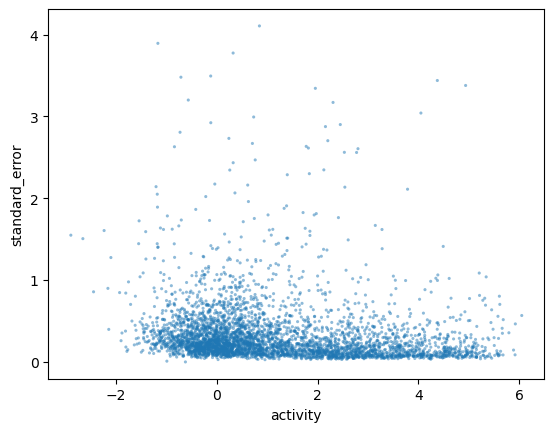

In [16]:
sns.scatterplot(data = final_results_to_share_CL, x = "activity", y = "standard_error", edgecolor = 'none', alpha  = 0.5, s = 5)

<Axes: xlabel='activity', ylabel='Count'>

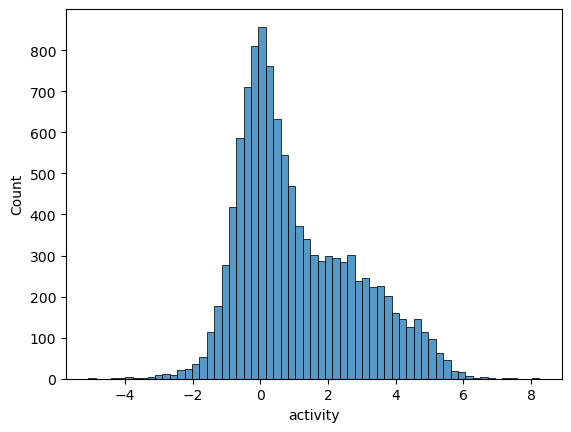

In [24]:
sns.histplot(data = final_results_to_share_CL, x = "activity")